### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score, precision_score, recall_score, average_precision_score, precision_recall_curve, roc_curve


### Loading Dataset

In [2]:
df=pd.read_csv(r"E:\Milind\Machine Learning\Dataset\transactions.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### EDA


In [3]:
df.shape

(284807, 31)

In [4]:
df.info() # there are no null values in the dataset

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.columns[df.isnull().sum()!=0] # there are no null values in the dataset

Index([], dtype='str')

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13,4.248366e-13,-3.054600e-13,8.777971e-14,-1.179749e-12,...,-3.405756e-13,-5.723197e-13,-9.725856e-13,1.464150e-12,-6.987102e-13,-5.617874e-13,3.332082e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


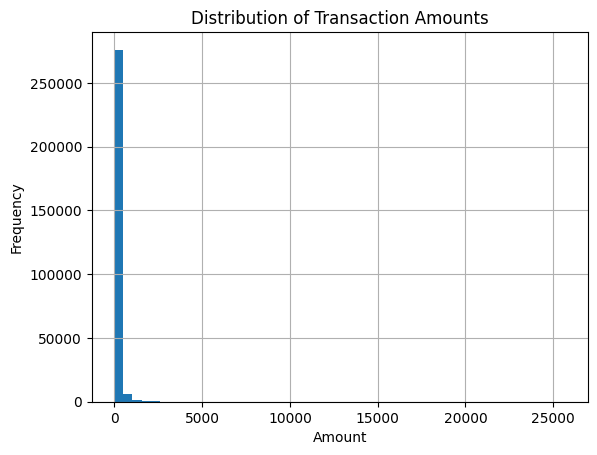

In [7]:
df['Amount'].hist(bins=50)
plt.xlabel('Amount')    
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts')
plt.show()
# maximum transaction amounts are low expect few outliers

In [8]:
df["Class"].value_counts() # Class 0 (non-fraudulent) is much more common than Class 1 (fraudulent)

Class
0    284315
1       492
Name: count, dtype: int64

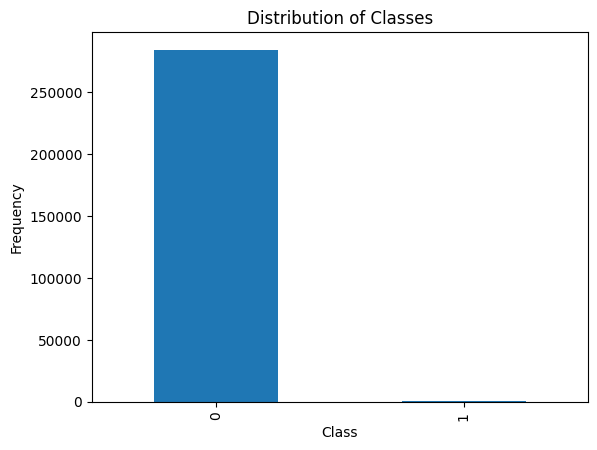

In [9]:
df["Class"].value_counts().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Distribution of Classes")
plt.show()
# the dataset is highly imbalanced with majority of transactions being non-fraudulent (Class 0) and a small proportion being fraudulent (Class 1).

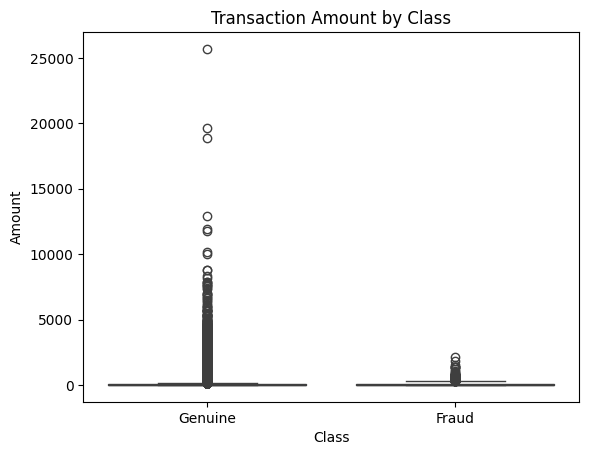

In [ ]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.xticks([0,1], ['Genuine', 'Fraud'])
plt.title("Transaction Amount by Class")
plt.show()
# this depicts that the transaction amount for fraudelent transaction(class 1) is lower 

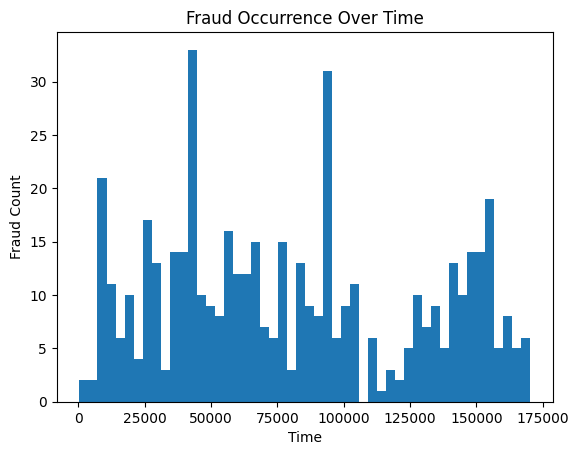

In [ ]:
fraud_df = df[df['Class'] == 1]
plt.hist(fraud_df['Time'], bins=50)
plt.xlabel("Time")
plt.ylabel("Fraud Count")
plt.title("Fraud Occurrence Over Time")
plt.show()
# The histogram shows that fraudulent transactions occur more frequently at certain times. This suggests that there may be specific time periods during which fraudulent activity is more prevalent, which could be useful for developing time-based fraud detection strategies.

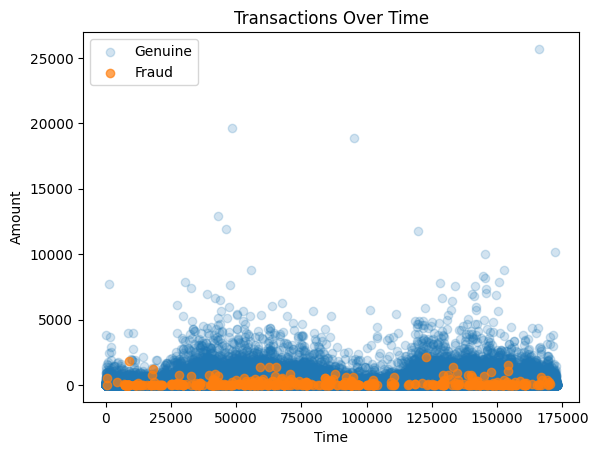

In [ ]:
plt.scatter(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'], alpha=0.2, label='Genuine')
plt.scatter(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],alpha=0.7,label='Fraud')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Amount")
plt.title("Transactions Over Time")
plt.show()
# The scatter plot reveals that fraudulent transactions (in orange) tend to cluster at certain times and often involve higher amounts compared to genuine transactions (in blue). This pattern suggests that fraudsters may target specific time periods and prefer larger transaction amounts, which could be critical insights for developing effective fraud detection algorithms.

In [49]:
df.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,3.777823e-12,-2.118614e-12,-1.733159e-13,-3.473231e-12,-1.306165e-13,-1.116494e-13,2.114527e-12,3.016285e-14,...,-3.276238e-12,2.281863e-12,-2.969746e-12,-1.029876e-12,1.144179e-12,1.835263e-12,7.624804e-12,-9.769215e-13,-0.227709,-0.101347
V2,-0.010593,3.777823e-12,1.000000e+00,2.325661e-12,-2.314981e-12,-1.831952e-12,9.438444e-13,5.403436e-12,2.133785e-14,3.238513e-13,...,2.280202e-12,-2.548560e-13,-4.856120e-12,6.431308e-13,-9.423730e-13,-4.129100e-13,-9.856545e-13,2.525513e-12,-0.531409,0.091289
V3,-0.419618,-2.118614e-12,2.325661e-12,1.000000e+00,2.046235e-13,-4.032993e-12,-1.574471e-13,3.405586e-12,-1.272385e-12,-6.812351e-13,...,6.736294e-13,-8.909339e-13,4.147209e-12,3.407636e-12,5.712956e-13,-2.577274e-12,-5.041444e-12,5.189109e-12,-0.210880,-0.192961
V4,-0.105260,-1.733159e-13,-2.314981e-12,2.046235e-13,1.000000e+00,-2.552389e-13,1.084041e-12,8.135064e-13,7.334818e-13,-7.143069e-13,...,-2.696370e-12,4.347776e-13,-4.160969e-12,-2.368743e-12,1.619944e-12,-3.043100e-13,-1.456066e-12,-2.832372e-12,0.098732,0.133447
V5,0.173072,-3.473231e-12,-1.831952e-12,-4.032993e-12,-2.552389e-13,1.000000e+00,-6.934789e-14,1.573956e-11,-2.038243e-12,-1.000756e-12,...,-1.751796e-12,7.095269e-13,3.616075e-12,-2.808776e-13,1.451126e-12,-1.896141e-13,-2.124559e-12,1.010196e-11,-0.386356,-0.094974
V6,-0.063016,-1.306165e-13,9.438444e-13,-1.574471e-13,1.084041e-12,-6.934789e-14,1.000000e+00,-2.798968e-12,-5.446480e-13,2.036743e-12,...,1.476858e-12,-1.144797e-12,-1.527842e-12,1.551854e-12,-2.723707e-12,3.351239e-12,1.481307e-12,-6.069227e-13,0.215981,-0.043643
V7,0.084714,-1.116494e-13,5.403436e-12,3.405586e-12,8.135064e-13,1.573956e-11,-2.798968e-12,1.000000e+00,5.528803e-12,5.088082e-13,...,2.788246e-12,-8.133209e-13,-4.293094e-12,-2.553518e-12,-7.406970e-13,-4.476467e-12,-1.328637e-11,2.958679e-13,0.397311,-0.187257
V8,-0.036949,2.114527e-12,2.133785e-14,-1.272385e-12,7.334818e-13,-2.038243e-12,-5.446480e-13,5.528803e-12,1.000000e+00,-2.243172e-12,...,-4.022440e-12,-2.679560e-12,9.013064e-13,-1.074365e-12,-3.268979e-12,1.043839e-12,-3.499804e-12,1.866598e-12,-0.103079,0.019875
V9,-0.008660,3.016285e-14,3.238513e-13,-6.812351e-13,-7.143069e-13,-1.000756e-12,2.036743e-12,5.088082e-13,-2.243172e-12,1.000000e+00,...,3.040326e-12,-7.467526e-13,-1.011003e-12,8.579072e-13,-1.590341e-12,-7.723547e-13,2.428930e-12,-1.406856e-12,-0.044246,-0.097733


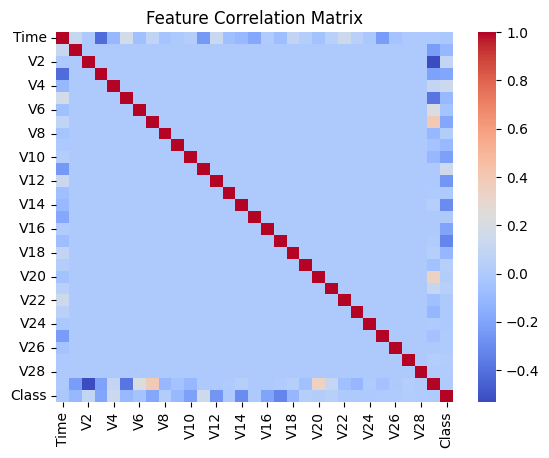

In [13]:
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()
# Most features are not strongly correlated with each other.
# class relates to each feature

### Data Preprocessing 
###### Not much used as dataset is clean and no null values 

In [14]:
X=df.drop('Class', axis=1)

In [15]:
y=df['Class']

### Train-Validation-Test Split

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3,stratify=y, random_state=42) # 70% training, 30% temp (validation + test)
# stratify=y ensures that the class distribution is preserved in the splits 
# this is important for imbalanced datasets to ensure that both the training and temp sets have a representative distribution of the classes.

In [17]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5,stratify=y_temp, random_state=42) # 15% validation, 15% test from the temp set
# stratify=y_temp ensures that the class distribution is preserved in the validation and test splits as well, which is crucial for evaluating model performance accurately on imbalanced datasets.


### Feature Scaling


In [18]:
scaler = StandardScaler()
X_train[["Amount", "Time"]] = scaler.fit_transform(X_train[["Amount", "Time"]])
X_val[["Amount", "Time"]] = scaler.transform(X_val[["Amount", "Time"]])
X_test[["Amount", "Time"]] = scaler.transform(X_test[["Amount", "Time"]])
# fit transform on training data but transform on validation and test data because they should remain unseen during training to evaluate model performance accurately.


In [52]:
y_train.value_counts()

Class
0    199020
1       344
Name: count, dtype: int64

### Imbalance Handling Method 

In [19]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
# SMOTE (Synthetic Minority Over-sampling Technique) is used to address class imbalance by generating synthetic samples for the minority class (fraudulent transactions) in the training set. This helps the model learn better from the minority class and improves its ability to detect fraud.


In [20]:
y_train_resampled.value_counts() # after resampling, the number of samples in each class is balanced, with 199020 samples for both Class 0 and Class 1. This indicates that SMOTE has successfully generated synthetic samples for the minority class (Class 1) to match the number of samples in the majority class (Class 0).

Class
0    199020
1    199020
Name: count, dtype: int64

### Model Training

##### Logistic Regression

In [21]:
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_resampled, y_train_resampled)
log_probs = log_model.predict_proba(X_val)[:,1] # predictions made on validation set
# Logistic Regression is a commonly used linear model for binary classification tasks. By setting class_weight='balanced', we are telling the model to give more weight to the minority class (fraudulent transactions) during training, which can help improve its performance on imbalanced datasets. The predict_proba method is used to get the predicted probabilities of the positive class (fraudulent transactions) for the validation set, which can be useful for evaluating model performance using metrics like ROC AUC.

In [53]:
log_probs

array([1.78654874e-04, 1.46757594e-03, 2.77255167e-07, ...,
       1.04486444e-02, 2.22235280e-02, 1.16175605e-01])


##### Random Forest Classifier

In [22]:
rf_model=RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1 ) # n_estimators are number of decision trees in the random forest, class_weight='balanced' helps to handle class imbalance by giving more weight to the minority class, random_state=42 ensures reproducibility of results, and n_jobs=-1 allows the model to use all available CPU cores for training, which can speed up the process.
rf_model.fit(X_train_resampled, y_train_resampled)
rf_probs = rf_model.predict_proba(X_val)[:,1]

##### XGB Model 

In [23]:
xgb_model = XGBClassifier( n_estimators=300,max_depth=6,learning_rate=0.05, subsample=0.8,colsample_bytree=0.8,eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)
xgb_probs = xgb_model.predict_proba(X_val)[:,1]

### Threshlod Optimization

##### Logistic Regression

In [ ]:
thresholds = np.arange(0.01, 1.0, 0.01)

best_threshold_log = 0
best_loss_log = float('inf')

losses_log = []

for threshold in thresholds:
    preds = (log_probs >= threshold).astype(int) # bool converted to int 
    
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel() # ravel flattens
    
    loss = fp + (25 * fn)
    
    losses_log.append(loss)
    
    if loss < best_loss_log:
        best_loss_log = loss
        best_threshold_log = threshold

In [54]:
best_threshold_log

0.99

In [63]:
final_probs_log=log_model.predict_proba(X_test)[:,1] # gets the probablity of fraud class 
final_preds_log = (final_probs_log >= best_threshold_log).astype(int) 

In [62]:
final_probs_log

array([8.19652390e-04, 4.20403711e-23, 1.57879503e-02, ...,
       5.44306216e-04, 4.34026529e-03, 2.12538116e-02])

In [64]:
final_preds_log

array([0, 0, 0, ..., 0, 0, 0])

##### Random Forest Classifier

In [26]:
thresholds = np.arange(0.01, 1.0, 0.01)

best_threshold_rf = 0
best_loss_rf = float('inf')

losses_rf = []

for threshold in thresholds:
    preds = (rf_probs >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    
    loss = fp + (25 * fn)
    
    losses_rf.append(loss)
    
    if loss < best_loss_rf:
        best_loss_rf = loss
        best_threshold_rf = threshold

In [55]:
best_threshold_rf

0.24000000000000002

In [27]:
final_probs_rf=rf_model.predict_proba(X_test)[:,1]
final_preds_rf = (final_probs_rf >= best_threshold_rf).astype(int)

##### XGBoost

In [28]:
thresholds = np.arange(0.01, 1.0, 0.01)

best_threshold_xgb = 0  
best_loss = float('inf')

losses = []

for threshold in thresholds:
    preds = (xgb_probs >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    
    loss = fp + (25 * fn)
    
    losses.append(loss)
    
    if loss < best_loss:
        best_loss = loss
        best_threshold_xgb = threshold

In [56]:
best_threshold_xgb

0.37

In [29]:
final_probs_xgb=xgb_model.predict_proba(X_test)[:,1]
final_preds_xgb = (final_probs_xgb >= best_threshold_xgb).astype(int)

### Final Evaluation Metrics

##### Logistic Regression

###### Evaluation Metrics

In [ ]:
accuracy = accuracy_score(y_test, final_preds_log)
precision = precision_score(y_test, final_preds_log)
recall = recall_score(y_test, final_preds_log)
f1 = f1_score(y_test, final_preds_log)
pr_auc = average_precision_score(y_test, final_probs_log)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("PR-AUC:", pr_auc)

Accuracy: 0.9989934928140068
Precision: 0.6666666666666666
Recall: 0.8378378378378378
F1 Score: 0.7425149700598802
ROC-AUC: 0.9655647487667747
PR-AUC: 0.7943114372437277


###### Precision Recall Curve

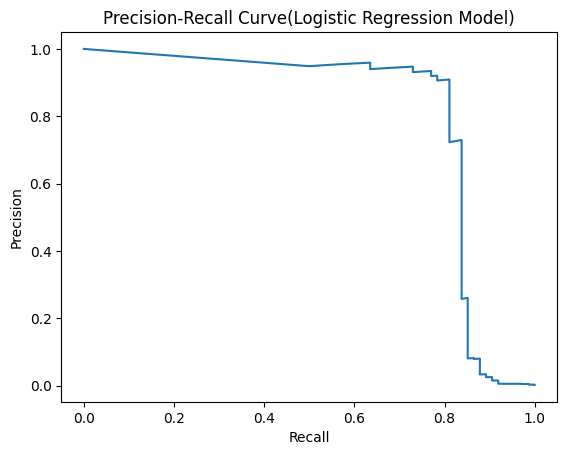

In [66]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, final_probs_log)
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve(Logistic Regression Model)")
plt.show()

###### Confusion Matrix

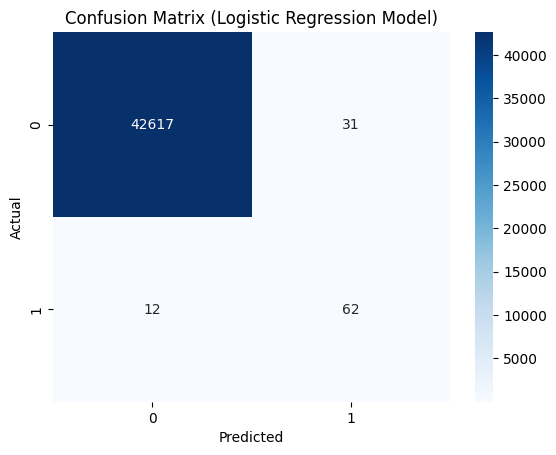

In [68]:
cm = confusion_matrix(y_test, final_preds_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression Model)")
plt.show()

###### Loss Calculation

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, final_preds_log).ravel() # flatten the confusion matrix to get tn, fp, fn, tp values
investigation_loss = fp + (25 * fn)

print("False Positives:", fp)
print("False Negatives:", fn)
print("Total Investigation Loss:", investigation_loss)

False Positives: 31
False Negatives: 12
Total Investigation Loss: 331


##### Random Forest Classifier

In [69]:
accuracy = accuracy_score(y_test, final_preds_rf)
precision = precision_score(y_test, final_preds_rf)
recall = recall_score(y_test, final_preds_rf)
f1 = f1_score(y_test, final_preds_rf)
pr_auc = average_precision_score(y_test, final_probs_rf)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("PR-AUC:", pr_auc)

Accuracy: 0.99922756425261
Precision: 0.7411764705882353
Recall: 0.8513513513513513
F1 Score: 0.7924528301886793
PR-AUC: 0.8316770014519272


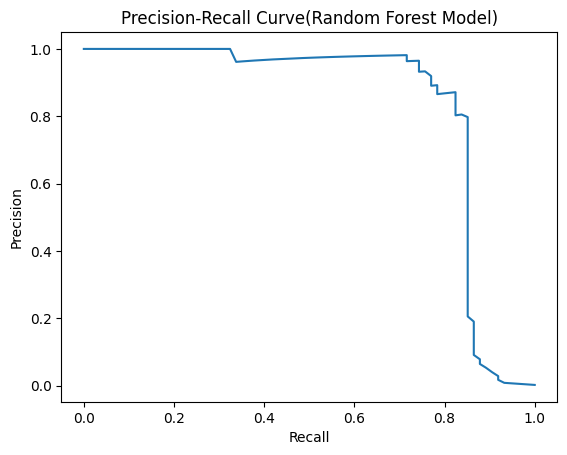

In [36]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, final_probs_rf)
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve(Random Forest Model)")
plt.show()

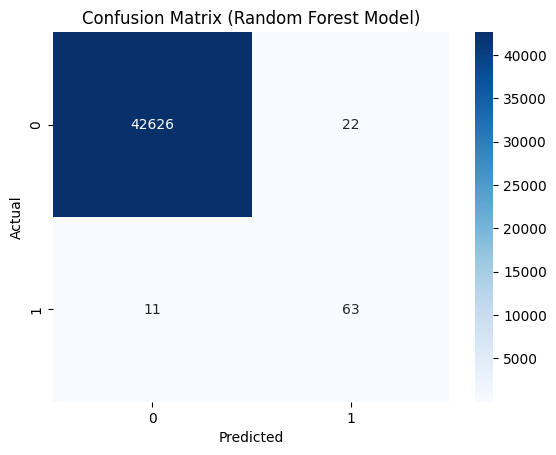

In [37]:
cm = confusion_matrix(y_test, final_preds_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest Model)")
plt.show()

In [39]:
tn, fp, fn, tp = confusion_matrix(y_test, final_preds_rf).ravel() 

investigation_loss = fp + (25 * fn)

print("False Positives:", fp)
print("False Negatives:", fn)

print("Total Investigation Loss:", investigation_loss)

False Positives: 22
False Negatives: 11
Total Investigation Loss: 297


##### XGBoost

In [70]:
accuracy = accuracy_score(y_test, final_preds_xgb)
precision = precision_score(y_test, final_preds_xgb)
recall = recall_score(y_test, final_preds_xgb)
f1 = f1_score(y_test, final_preds_xgb)
pr_auc = average_precision_score(y_test, final_probs_xgb)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("PR-AUC:", pr_auc)

Accuracy: 0.9977763213332709
Precision: 0.42758620689655175
Recall: 0.8378378378378378
F1 Score: 0.5662100456621004
PR-AUC: 0.8201607442376151


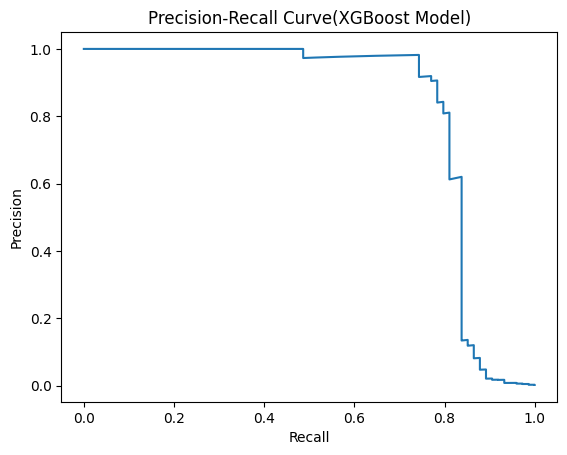

In [41]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, final_probs_xgb)
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve(XGBoost Model)")
plt.show()

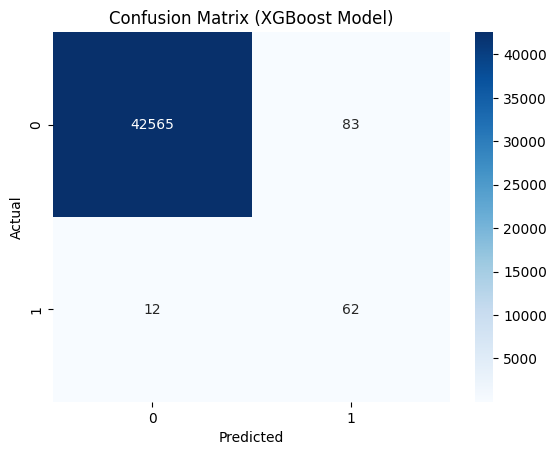

In [42]:
cm = confusion_matrix(y_test, final_preds_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (XGBoost Model)")
plt.show()

In [44]:
tn, fp, fn, tp = confusion_matrix(y_test, final_preds_xgb).ravel()
investigation_loss = fp + (25 * fn)

print("False Positives:", fp)
print("False Negatives:", fn)

print("Total Investigation Loss:", investigation_loss)

False Positives: 83
False Negatives: 12
Total Investigation Loss: 383


### Model Comparision

In [75]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, final_preds_log), accuracy_score(y_test, final_preds_rf), accuracy_score(y_test, final_preds_xgb)],
    "Precision": [precision_score(y_test, final_preds_log), precision_score(y_test, final_preds_rf), precision_score(y_test, final_preds_xgb)],
    "Recall": [recall_score(y_test, final_preds_log), recall_score(y_test, final_preds_rf), recall_score(y_test, final_preds_xgb)],
    "F1 Score": [f1_score(y_test, final_preds_log), f1_score(y_test, final_preds_rf), f1_score(y_test, final_preds_xgb)],
    "PR-AUC": [average_precision_score(y_test, final_probs_log), average_precision_score(y_test, final_probs_rf), average_precision_score(y_test, final_probs_xgb)]
})
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,PR-AUC
0,Logistic Regression,0.998993,0.666667,0.837838,0.742515,0.794311
1,Random Forest,0.999228,0.741176,0.851351,0.792453,0.831677
2,XGBoost,0.997776,0.427586,0.837838,0.566210,0.820161


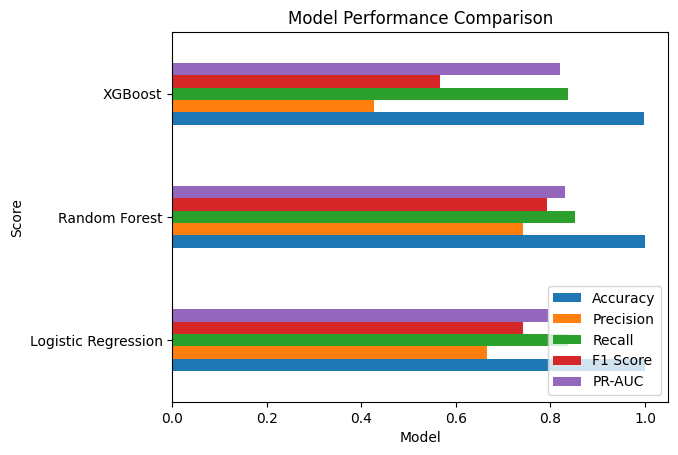

In [76]:
comparison_df.plot(x="Model",kind="barh")
plt.legend()
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.show()